In [1]:
# ── Install any missing packages (run once) ──────────────────────────────────
!pip install pandas numpy matplotlib seaborn plotly scipy statsmodels
!pip install scikit-learn xgboost lightgbm lifelines geopandas folium
!pip install pmdarima prophet openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   -------------- ------------------------- 262.1/715.6 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/715.6 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 715.6/715.6 kB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.7 MB/s eta 0:00:07
   - -------------------------------------- 0.5/12.1 MB 1.7 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/12.1 MB 2.3 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/12.1 MB 2.3 MB/s eta 0:00:05
   ------- -------------------------------- 2.4/12.1 MB 2.1 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.1 MB 2.2 MB/s eta 0:00:05
   ------------


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:


import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import logit

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts

# Time-series
from prophet import Prophet          # uncomment if installed
from pmdarima import auto_arima      # uncomment if installed

#Geo (optional — comment out if geopandas not installed)
import geopandas as gpd
import folium

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})


##  0.1 Load Dataset

In [4]:
import pandas as pd
tb_dataset = pd.read_csv("final_dataset.csv")

df = tb_dataset.copy()   # working copy — tb_dataset stays untouched

print(f'Shape : {df.shape}')
print(f'Columns ({len(df.columns)}):\n', df.columns.tolist())
df.head()

Shape : (8549, 96)
Columns (96):
 ['organisation_unit_name', 'enrollment_date_diagnostic_date', 'year', 'month', 'fy', 'district', 'method_of_tb_confirmation', 'tb_location_of_disease', 'site_of_disease', 'tb_classification_ds_or_dr', 'previous_treatment_history', 'genexpert_results_-_mtb', 'genexpert_-_mtb_sample_collection_date', 'genexpert_results_-_rifampicin', 'genexpert_lab_result_date', 'smear_specimen_result', 'smear_lab_result_date', 'd#nt', 'who_categorization', 'mwrd', 'dst', 'culture_specimen_test_result', 'tb_lam_test', 'tb_lam_result', 'hiv_status', 'history_of_hiv', 'currently_on_cotrimoxazole', 'cotrimoxazole_start_date', 'currently_on_art', 'art_start_date', 'sex', 'date_of_birth', 'tb_current_age', 'age_cat', 'age_group', 'hrg_cat', 'hrg', 'tb_case_referred_by_new', 'contact_of_tpb+', 'contact_of_mdr_-_tb', 'diabetic_new', 'health_facility_worker_new', 'community_health_workers', 'mining_worker_new', 'prisoners', 'refugee', 'transit_or_rehabilitation_center', 'cdt_of_

,organisation_unit_name,enrollment_date_diagnostic_date,year,month,fy,district,method_of_tb_confirmation,tb_location_of_disease,site_of_disease,tb_classification_ds_or_dr,...,number_of_positive_tb_cases_among_contacts_≥5_years,contacts_of_tpb+_≥_5_years_tst_done,contacts_of_tpb+_≥_5_years_tst_positive,contacts_of_tpb+≥_5_years_put_on_tpt,number_of_≥_5_years_contacts_with_tpt_completed,number_of_≥_5_years_on_tpt_lost_to_follow_up,number_of_≥_5_years_on_tpt_who_died,number_of_≥_5_years_who_developed_active_tb_while_on_tpt,number_of_≥_5_years_with_tpt_discontinuation_due_to_side_effects,number_of_≥_5_years_on_tpt_not_evaluated
0,Ruhengeri RH,2024-04-02 00:00:00.000,1970-01-01,4,FY 2023-2024,Musanze District,Clinically diagnosed,Pleural TB,Extra pulmonary,DS-TB,...,0,0,0,0,0,0,0,0,0,0
1,Kicukiro CS,2024-03-05 00:00:00.000,1970-01-01,3,FY 2023-2024,Kicukiro District,Bacteriologically confirmed,Unknown,Pulmonary,DS-TB,...,0,0,0,0,0,0,0,0,0,0
2,Kairos CS,2024-02-02 00:00:00.000,1970-01-01,2,FY 2023-2024,Kicukiro District,Bacteriologically confirmed,Unknown,Pulmonary,DS-TB,...,0,0,0,0,0,0,0,0,0,0
3,Kicukiro CS,2024-03-15 00:00:00.000,1970-01-01,3,FY 2023-2024,Kicukiro District,Bacteriologically confirmed,Unknown,Pulmonary,DS-TB,...,0,0,0,0,0,0,0,0,0,0
4,Rubavu Prison,2024-04-05 00:00:00.000,1970-01-01,4,FY 2023-2024,Rubavu District,Bacteriologically confirmed,Unknown,Pulmonary,DS-TB,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Data types & missing values 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'Missing_N': missing, 'Missing_%': missing_pct, 'Dtype': df.dtypes})
summary[summary['Missing_N'] > 0].sort_values('Missing_%', ascending=False)

,Missing_N,Missing_%,Dtype
bmi_cat_at_beginning,8549,100.00,float64
bmi_cat_at_end_treatment,8549,100.00,float64
mdr_date_of_interim_outcome_at_6_months,8519,99.65,object
cotrimoxazole_start_date,8081,94.53,object
art_start_date,7554,88.36,object
smear_lab_result_date,7071,82.71,object
date_of_control_at_the_end_of_tb_treatment_new,5814,68.01,object
date_of_control_at_the_end_of_month_5_c5,5599,65.49,object
date_of_control_at_the_end_of_month_2_c2,3957,46.29,object
genexpert_lab_result_date,2028,23.72,object


In [7]:
df.columns.to_list()

['organisation_unit_name',
 'enrollment_date_diagnostic_date',
 'year',
 'month',
 'fy',
 'district',
 'method_of_tb_confirmation',
 'tb_location_of_disease',
 'site_of_disease',
 'tb_classification_ds_or_dr',
 'previous_treatment_history',
 'genexpert_results_-_mtb',
 'genexpert_-_mtb_sample_collection_date',
 'genexpert_results_-_rifampicin',
 'genexpert_lab_result_date',
 'smear_specimen_result',
 'smear_lab_result_date',
 'd#nt',
 'who_categorization',
 'mwrd',
 'dst',
 'culture_specimen_test_result',
 'tb_lam_test',
 'tb_lam_result',
 'hiv_status',
 'history_of_hiv',
 'currently_on_cotrimoxazole',
 'cotrimoxazole_start_date',
 'currently_on_art',
 'art_start_date',
 'sex',
 'date_of_birth',
 'tb_current_age',
 'age_cat',
 'age_group',
 'hrg_cat',
 'hrg',
 'tb_case_referred_by_new',
 'contact_of_tpb+',
 'contact_of_mdr_-_tb',
 'diabetic_new',
 'health_facility_worker_new',
 'community_health_workers',
 'mining_worker_new',
 'prisoners',
 'refugee',
 'transit_or_rehabilitation_cente

In [8]:
# ── Column standardisation — mapped to your exact dataset columns ─────────────
# Your CSV already uses snake_case, so most columns need no renaming.
# This cell creates clean short aliases used throughout the rest of the notebook.

RENAME = {

    # ── Facility / Geography ──────────────────────────────────────────────────
    'organisation_unit_name':                       'facility',
    # 'district' already named correctly — no rename needed
    # 'year', 'month', 'fy' already correct

    # ── Dates ────────────────────────────────────────────────────────────────
    'enrollment_date_diagnostic_date':              'date_notified',
    'genexpert_-_mtb_sample_collection_date':       'date_xpert_collected',
    'genexpert_lab_result_date':                    'date_xpert_result',
    'smear_lab_result_date':                        'date_smear_result',
    'cotrimoxazole_start_date':                     'date_cotrimoxazole_start',
    'art_start_date':                               'date_art_start',
    'start_treatment':                              'date_treatment_start',
    'date_of_control_at_the_end_of_month_2_c2':    'date_control_m2',
    'date_of_control_at_the_end_of_month_5_c5':    'date_control_m5',
    'date_of_control_at_the_end_of_tb_treatment_new': 'date_control_end',
    'mdr_date_of_interim_outcome_at_6_months':      'date_mdr_interim',

    # ── Demographics ─────────────────────────────────────────────────────────
    'date_of_birth':                                'dob',
    'tb_current_age':                               'age',
    # 'sex' already correct
    'age_cat':                                      'age_cat',
    # 'age_group' already correct

    # ── TB Classification ─────────────────────────────────────────────────────
    'method_of_tb_confirmation':                    'bact_confirmed',
    'tb_location_of_disease':                       'tb_type',       # Pulmonary/Extra-pulmonary
    # 'site_of_disease' already correct
    'tb_classification_ds_or_dr':                   'drug_sensitivity',
    'previous_treatment_history':                   'tb_category',   # New/Relapse/Retreatment
    'who_categorization':                           'who_category',
    'treatment_category/regimen':                   'treatment_regimen',

    # ── Diagnostic / Lab ─────────────────────────────────────────────────────
    'genexpert_results_-_mtb':                      'xpert_result',
    'genexpert_results_-_rifampicin':               'xpert_rifampicin',
    'smear_specimen_result':                        'smear_result',
    'culture_specimen_test_result':                 'culture_result',
    'tb_lam_test':                                  'tb_lam_test',
    'tb_lam_result':                                'tb_lam_result',
    'dst':                                          'dst_result',
    'mwrd':                                         'mwrd',
    'd#nt':                                         'dnt',           # Days-not-treated

    # ── HIV ──────────────────────────────────────────────────────────────────
    # 'hiv_status' already correct
    'history_of_hiv':                               'hiv_history',
    'currently_on_cotrimoxazole':                   'on_cotrimoxazole',
    'currently_on_art':                             'on_art',

    # ── Anthropometrics ──────────────────────────────────────────────────────
    'weight_at_the_tb_treatment_initiation_kg_new': 'weight_start_kg',
    'height_cm_new':                                'height_cm',
    'bmi_at_beginning':                             'bmi_start',
    'bmi_cat_at_beginning':                         'bmi_cat_start',
    'weight_at_the_end_of_tb_treatment_kg_new':     'weight_end_kg',
    'bmi_at_end_treatment':                         'bmi_end',
    'bmi_cat_at_end_treatment':                     'bmi_cat_end',

    # ── Treatment / Follow-up ─────────────────────────────────────────────────
    'control_at_the_end_of_month_2_c2':             'control_m2',
    'control_at_the_end_of_month_5_c5':             'control_m5',
    'control_at_the_end_of_tb_treatment_new':       'control_end',
    'is_there_side_effect':                         'side_effect',
    'followed_by_chw_new':                          'chw_followup',
    'tb_nutrition_support_provided':                'nutrition_support',

    # ── Treatment Outcomes ────────────────────────────────────────────────────
    # 'treatment_outcome' already correct
    'mdr_treatment_outcome':                        'mdr_outcome',
    'treatment_at_start_-_shorter_mdr-tb_regimen':  'mdr_regimen_start',
    'mdr_interim_outcome_culture_results':          'mdr_interim_culture',

    # ── Referral / Category ───────────────────────────────────────────────────
    'tb_case_referred_by_new':                      'referred_by',
    'cdt_of_diagnosis':                             'cdt_diagnosis',
    'cdt_of_origin':                                'cdt_origin',
    'hrg_cat':                                      'hrg_cat',
    'hrg':                                          'hrg',

    # ── High-Risk Groups ──────────────────────────────────────────────────────
    'contact_of_tpb+':                              'contact_tb_pos',
    'contact_of_mdr_-_tb':                          'contact_mdr_tb',
    'diabetic_new':                                 'diabetic',
    'health_facility_worker_new':                   'health_worker',
    'community_health_workers':                     'chw',
    'mining_worker_new':                            'miner',
    # 'prisoners' already correct
    # 'refugee' already correct
    'transit_or_rehabilitation_center':             'transit_rehab',

    # ── Contacts — Index Case ─────────────────────────────────────────────────
    'number_of_contacts_of_tpb+_index_case':        'contacts_total',

    # ── Contacts < 5 years ────────────────────────────────────────────────────
    'number_of_contacts_<5_years_living_with_index_case':   'contacts_u5_living',
    'number_of_contacts_<5_years_screened_for_tb':          'contacts_u5_screened',
    'number_of_positive_tb_cases_among_contacts_<5_years':  'contacts_u5_tb_pos',
    'contacts_of_tpb+<_2_years_put_on_ipt/tpt':             'tpt_started_u2',
    'contacts_of_tpb+_2_-_5_years_put_on_ipt/tpt':          'tpt_started_2to5',
    'number_of_<_5_years_contacts_with_tpt_completed':       'tpt_completed_u5',
    'number_of_<_5_years_on_tpt_lost_to_follow_up':          'tpt_ltfu_u5',
    'number_of_<_5_years_on_tpt_who_died':                   'tpt_died_u5',
    'number_of_<_5_years_with_tpt_discontinuation_due_to_side_effects': 'tpt_se_u5',
    'number_of_<_5_years_on_tpt_not_evaluated':              'tpt_not_eval_u5',
    'number_of_<_5_years_who_developed_active_tb_while_on_tpt': 'tpt_active_tb_u5',

    # ── Contacts ≥ 5 years ────────────────────────────────────────────────────
    'number_of_contacts_≥5_years_living_with_index_case':    'contacts_5plus_living',
    'number_of_contacts_≥5_years_screened_for_tb':           'contacts_5plus_screened',
    'number_of_positive_tb_cases_among_contacts_≥5_years':   'contacts_5plus_tb_pos',
    'contacts_of_tpb+_≥_5_years_tst_done':                   'tst_done_5plus',
    'contacts_of_tpb+_≥_5_years_tst_positive':               'tst_positive_5plus',
    'contacts_of_tpb+≥_5_years_put_on_tpt':                  'tpt_started_5plus',
    'number_of_≥_5_years_contacts_with_tpt_completed':        'tpt_completed_5plus',
    'number_of_≥_5_years_on_tpt_lost_to_follow_up':           'tpt_ltfu_5plus',
    'number_of_≥_5_years_on_tpt_who_died':                    'tpt_died_5plus',
    'number_of_≥_5_years_who_developed_active_tb_while_on_tpt': 'tpt_active_tb_5plus',
    'number_of_≥_5_years_with_tpt_discontinuation_due_to_side_effects': 'tpt_se_5plus',
    'number_of_≥_5_years_on_tpt_not_evaluated':               'tpt_not_eval_5plus',
}

df.rename(columns={k: v for k, v in RENAME.items() if k in df.columns}, inplace=True)
print('✅ Columns after rename:')
print(df.columns.tolist())

# ── Quick sanity check: confirm key aliases exist ─────────────────────────────
EXPECTED = [
    'facility', 'district', 'year', 'month', 'fy',
    'age', 'sex', 'age_group',
    'date_notified', 'date_treatment_start',
    'tb_type', 'site_of_disease', 'drug_sensitivity', 'tb_category', 'bact_confirmed',
    'xpert_result', 'smear_result',
    'hiv_status',
    'treatment_outcome',
    'contacts_total', 'contacts_u5_living', 'contacts_5plus_living',
    'tpt_completed_u5', 'tpt_completed_5plus',
    'prisoners', 'refugee', 'miner',
]

missing = [c for c in EXPECTED if c not in df.columns]
if missing:
    print(f'\n⚠️  These expected columns were NOT found after rename:')
    for m in missing:
        print(f'   • {m}')
else:
    print('\n✅ All expected key columns found.')

✅ Columns after rename:
['facility', 'date_notified', 'year', 'month', 'fy', 'district', 'bact_confirmed', 'tb_type', 'site_of_disease', 'drug_sensitivity', 'tb_category', 'xpert_result', 'date_xpert_collected', 'xpert_rifampicin', 'date_xpert_result', 'smear_result', 'date_smear_result', 'dnt', 'who_category', 'mwrd', 'dst_result', 'culture_result', 'tb_lam_test', 'tb_lam_result', 'hiv_status', 'hiv_history', 'on_cotrimoxazole', 'date_cotrimoxazole_start', 'on_art', 'date_art_start', 'sex', 'dob', 'age', 'age_cat', 'age_group', 'hrg_cat', 'hrg', 'referred_by', 'contact_tb_pos', 'contact_mdr_tb', 'diabetic', 'health_worker', 'chw', 'miner', 'prisoners', 'refugee', 'transit_rehab', 'cdt_diagnosis', 'cdt_origin', 'weight_start_kg', 'height_cm', 'date_treatment_start', 'bmi_cat_start', 'bmi_start', 'treatment_regimen', 'chw_followup', 'nutrition_support', 'control_m2', 'date_control_m2', 'control_m5', 'date_control_m5', 'control_end', 'date_control_end', 'side_effect', 'treatment_outcome'

In [10]:
# ── Parse all date columns ────────────────────────────────────────────────────
DATE_COLS = [
    'date_notified',
    'date_xpert_collected',
    'date_xpert_result',
    'date_smear_result',
    'date_cotrimoxazole_start',
    'date_art_start',
    'date_treatment_start',
    'date_control_m2',
    'date_control_m5',
    'date_control_end',
    'date_mdr_interim',
    'dob',
]

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        n_parsed = df[col].notna().sum()
        print(f'  {col:<30} → {n_parsed:,} valid dates')

# ── year / month / fy — already in dataset, just ensure numeric ───────────────
for col in ['year', 'month', 'fy']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fallback: derive from date_notified if year/month are mostly missing
if df['year'].isna().mean() > 0.5 and 'date_notified' in df.columns:
    df['year']  = df['date_notified'].dt.year
    df['month'] = df['date_notified'].dt.month
    print('  year/month derived from date_notified (original columns were mostly empty)')

if 'quarter' not in df.columns and 'date_notified' in df.columns:
    df['quarter'] = df['date_notified'].dt.quarter

# ── Age — already 'age', just ensure numeric ──────────────────────────────────
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# ── Standardised age_group (use existing age_group if present, else create) ───
if df['age_group'].isna().mean() > 0.5 or df['age_group'].nunique() > 15:
    # Recreate with standard WHO bins
    bins   = [0, 5, 15, 25, 35, 45, np.inf]
    labels = ['0–4', '5–14', '15–24', '25–34', '35–44', '45+']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
    print('  age_group recreated from age using WHO bins (0–4, 5–14, 15–24, 25–34, 35–44, 45+)')
else:
    print(f'  age_group kept as-is  ({df["age_group"].nunique()} unique values: {df["age_group"].unique().tolist()})')

# ── Derived: diagnostic delay (enrollment → xpert result) ────────────────────
if 'date_notified' in df.columns and 'date_xpert_result' in df.columns:
    df['diag_delay_days'] = (df['date_xpert_result'] - df['date_notified']).dt.days.clip(lower=0)

# ── Derived: treatment duration (start → end-of-treatment control) ────────────
if 'date_treatment_start' in df.columns and 'date_control_end' in df.columns:
    df['treatment_days'] = (df['date_control_end'] - df['date_treatment_start']).dt.days.clip(lower=0)

# ── Derived: BMI at start (if weight & height present but bmi_start missing) ──
if df['bmi_start'].isna().mean() > 0.9:
    df['weight_start_kg'] = pd.to_numeric(df['weight_start_kg'], errors='coerce')
    df['height_cm']       = pd.to_numeric(df['height_cm'],       errors='coerce')
    height_m = df['height_cm'] / 100
    df['bmi_start'] = (df['weight_start_kg'] / (height_m ** 2)).round(1)
    print('  bmi_start calculated from weight_start_kg and height_cm')

# ── Derived: weight change during treatment ───────────────────────────────────
df['weight_end_kg']   = pd.to_numeric(df['weight_end_kg'],   errors='coerce')
df['weight_start_kg'] = pd.to_numeric(df['weight_start_kg'], errors='coerce')
df['weight_change_kg'] = df['weight_end_kg'] - df['weight_start_kg']

# ── Derived: binary outcome flags (used in ML & survival sections) ────────────
if 'treatment_outcome' in df.columns:
    SUCCESS_LABELS = ['cured', 'treatment completed', 'success', 'successful',
                      'treatment_completed', 'Cured', 'Treatment Completed']
    DIED_LABELS    = ['died', 'death', 'dead', 'Died', 'Death']
    LTFU_LABELS    = ['lost to follow-up', 'ltfu', 'lost', 'Lost to Follow-up',
                      'Lost to follow-up', 'LTFU']
    FAILED_LABELS  = ['failed', 'failure', 'treatment failed', 'Failed', 'Treatment Failed']

    df['outcome_success'] = df['treatment_outcome'].str.strip().str.lower().isin(
        [s.lower() for s in SUCCESS_LABELS]).astype(int)
    df['died']            = df['treatment_outcome'].str.strip().str.lower().isin(
        [s.lower() for s in DIED_LABELS]).astype(int)
    df['ltfu']            = df['treatment_outcome'].str.strip().str.lower().isin(
        [s.lower() for s in LTFU_LABELS]).astype(int)
    df['tx_failed']       = df['treatment_outcome'].str.strip().str.lower().isin(
        [s.lower() for s in FAILED_LABELS]).astype(int)

# ── Derived: DR-TB flag ───────────────────────────────────────────────────────
if 'drug_sensitivity' in df.columns:
    df['is_dr'] = df['drug_sensitivity'].astype(str).str.upper().str.contains(
        'DR|MDR|RR|XDR', na=False).astype(int)

# ── Derived: HIV-positive flag ────────────────────────────────────────────────
if 'hiv_status' in df.columns:
    df['hiv_pos'] = df['hiv_status'].astype(str).str.strip().str.lower().isin(
        ['positive', 'pos', 'hiv+', 'hiv positive', 'reactive']).astype(int)

# ── Derived: TPT started (any age group) ─────────────────────────────────────
tpt_start_cols = ['tpt_started_u2', 'tpt_started_2to5', 'tpt_started_5plus']
available_tpt  = [c for c in tpt_start_cols if c in df.columns]
if available_tpt:
    for c in available_tpt:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    df['tpt_started_total'] = df[available_tpt].sum(axis=1)

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n Derived columns created:')
derived = ['age_group', 'quarter', 'diag_delay_days', 'treatment_days',
           'bmi_start', 'weight_change_kg',
           'outcome_success', 'died', 'ltfu', 'tx_failed',
           'is_dr', 'hiv_pos', 'tpt_started_total']
for col in derived:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        print(f'  {col:<25} {n_valid:,} non-null values')

print(f'\nFinal dataset shape: {df.shape}')
df.head(3)

  date_notified                  → 1,041 valid dates
  date_xpert_collected           → 6,522 valid dates
  date_xpert_result              → 6,521 valid dates
  date_smear_result              → 1,478 valid dates
  date_cotrimoxazole_start       → 468 valid dates
  date_art_start                 → 995 valid dates
  date_treatment_start           → 0 valid dates
  date_control_m2                → 4,592 valid dates
  date_control_m5                → 2,950 valid dates
  date_control_end               → 2,735 valid dates
  date_mdr_interim               → 30 valid dates
  dob                            → 8,549 valid dates
  year/month derived from date_notified (original columns were mostly empty)
  age_group kept as-is  (8 unique values: ['25-34 years', '65+ ', '35-44 years', '55-64 years', '15-24 years', '45-54 years', '<5years', '5-14 years'])

 Derived columns created:
  age_group                 8,549 non-null values
  quarter                   1,041 non-null values
  diag_delay_days  

,facility,date_notified,year,month,fy,district,bact_confirmed,tb_type,site_of_disease,drug_sensitivity,...,diag_delay_days,treatment_days,weight_change_kg,outcome_success,died,ltfu,tx_failed,is_dr,hiv_pos,tpt_started_total
0,Ruhengeri RH,2024-04-02,2024.0,4.0,NaN,Musanze District,Clinically diagnosed,Pleural TB,Extra pulmonary,DS-TB,...,NaN,NaN,-58.0,0,0,0,0,0,0,0
1,Kicukiro CS,2024-03-05,2024.0,3.0,NaN,Kicukiro District,Bacteriologically confirmed,Unknown,Pulmonary,DS-TB,...,0.0,NaN,-54.0,0,0,0,0,0,1,0
2,Kairos CS,2024-02-02,2024.0,2.0,NaN,Kicukiro District,Bacteriologically confirmed,Unknown,Pulmonary,DS-TB,...,1.0,NaN,-45.0,0,0,0,0,0,0,0


In [13]:
# ── FIX 1: date_treatment_start has 0 valid dates ────────────────────────────
# The column 'start_treatment' may have been stored as a string or different format.
# Investigate the raw values first.

print('=== FIX 1: Investigate date_treatment_start ===')
print('Sample raw values:')
print(df['date_treatment_start'].dropna().head(10).tolist())
print(f'Dtype: {df["date_treatment_start"].dtype}')
print(f'Unique non-null count: {df["date_treatment_start"].nunique()}')
print(f'Sample unique values: {df["date_treatment_start"].unique()[:10]}')

# Try multiple date formats common in African health systems
for fmt in ['%d/%m/%Y', '%Y-%m-%d', '%m/%d/%Y', '%d-%m-%Y', '%Y/%m/%d', '%d.%m.%Y']:
    try:
        test = pd.to_datetime(df['date_treatment_start'], format=fmt, errors='coerce')
        n = test.notna().sum()
        if n > 100:
            df['date_treatment_start'] = test
            print(f'\n Parsed with format {fmt} → {n:,} valid dates')
            break
    except Exception:
        continue
else:
    # Last resort: let pandas infer
    df['date_treatment_start'] = pd.to_datetime(df['date_treatment_start'],
                                                  infer_datetime_format=True,
                                                  errors='coerce')
    n = df['date_treatment_start'].notna().sum()
    print(f'\nPandas infer → {n:,} valid dates')

# If still 0, derive treatment start from date_notified (enrollment = diagnosis = treatment start
# is common in TB programs with same-day treatment initiation)
if df['date_treatment_start'].notna().sum() < 100:
    print('\n  date_treatment_start still empty.')
    print('   Falling back to date_notified as proxy for treatment start.')
    print('   (Common in TB programs where diagnosis & treatment start same day)')
    df['date_treatment_start'] = df['date_notified']
    df['tx_start_is_proxy'] = True
else:
    df['tx_start_is_proxy'] = False

# Recalculate treatment_days now that date_treatment_start is fixed
df['treatment_days'] = (df['date_control_end'] - df['date_treatment_start']).dt.days.clip(lower=0)
print(f'\ntreatment_days — valid: {df["treatment_days"].notna().sum():,}')
print(df['treatment_days'].describe().round(1))


# ── FIX 2: Standardise age_group labels ──────────────────────────────────────
# Your dataset uses labels like '25-34 years', '<5years', '65+ ' (with trailing space)
# Standardise to clean short labels used throughout the notebook.

print('\n=== FIX 2: Standardise age_group labels ===')
print('Before:', df['age_group'].value_counts().to_dict())

AGE_LABEL_MAP = {
    '<5years':     '0–4',
    '<5 years':    '0–4',
    '0-4 years':   '0–4',
    '5-14 years':  '5–14',
    '5-14years':   '5–14',
    '15-24 years': '15–24',
    '15-24years':  '15–24',
    '25-34 years': '25–34',
    '25-34years':  '25–34',
    '35-44 years': '35–44',
    '35-44years':  '35–44',
    '45-54 years': '45–54',
    '45-54years':  '45–54',
    '55-64 years': '55–64',
    '55-64years':  '55–64',
    '65+ ':        '65+',
    '65+':         '65+',
    '65+ years':   '65+',
    '65+years':    '65+',
}

# Strip whitespace first, then map
df['age_group'] = df['age_group'].astype(str).str.strip().map(
    lambda x: AGE_LABEL_MAP.get(x, x)
)

# Define ordered category for correct sort order in all plots
AGE_ORDER = ['0–4', '5–14', '15–24', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_group'] = pd.Categorical(df['age_group'],
                                  categories=AGE_ORDER,
                                  ordered=True)

print('After:', df['age_group'].value_counts().sort_index().to_dict())
print(f'Null age_group: {df["age_group"].isna().sum()}')


# ── FIX 3: quarter coverage — only 1,041 because date_notified was sparse ─────
# Use dob or date_xpert_collected as secondary date source for quarter/year
# where date_notified is missing

print('\n=== FIX 3: Improve year / month / quarter coverage ===')

# Priority: date_notified → date_xpert_collected → date_xpert_result
for fallback_col in ['date_xpert_collected', 'date_xpert_result']:
    if fallback_col in df.columns:
        mask = df['year'].isna() & df[fallback_col].notna()
        df.loc[mask, 'year']    = df.loc[mask, fallback_col].dt.year
        df.loc[mask, 'month']   = df.loc[mask, fallback_col].dt.month
        df.loc[mask, 'quarter'] = df.loc[mask, fallback_col].dt.quarter
        filled = mask.sum()
        if filled > 0:
            print(f'  Filled {filled:,} year/month/quarter from {fallback_col}')

# Fiscal year (April start — adjust FY_START_MONTH if your country uses a different FY)
FY_START_MONTH = 4
def calc_fy(row):
    if pd.isna(row['year']) or pd.isna(row['month']):
        return np.nan
    return int(row['year']) if int(row['month']) >= FY_START_MONTH else int(row['year']) - 1

df['fy'] = df.apply(calc_fy, axis=1)

print(f'\n  year    — {df["year"].notna().sum():,} non-null')
print(f'  month   — {df["month"].notna().sum():,} non-null')
print(f'  quarter — {df["quarter"].notna().sum():,} non-null')
print(f'  fy      — {df["fy"].notna().sum():,} non-null')

# Year distribution
print('\nCases per year:')
print(df['year'].value_counts().sort_index().to_frame('N'))


# ── Final derived column summary ──────────────────────────────────────────────
print('\n All fixes applied. Key column status:')
check_cols = {
    'date_treatment_start': 'Date (treatment start)',
    'treatment_days':       'Treatment duration (days)',
    'age_group':            'Age group (standardised)',
    'year':                 'Year',
    'quarter':              'Quarter',
    'fy':                   'Fiscal year',
}
for col, label in check_cols.items():
    n = df[col].notna().sum()
    pct = n / len(df) * 100
    print(f'  {label:<30} {n:,} / {len(df):,}  ({pct:.1f}%)')

=== FIX 1: Investigate date_treatment_start ===
Sample raw values:
[Timestamp('2024-04-02 00:00:00'), Timestamp('2024-03-05 00:00:00'), Timestamp('2024-02-02 00:00:00'), Timestamp('2024-03-15 00:00:00'), Timestamp('2024-04-05 00:00:00'), Timestamp('2024-03-18 00:00:00'), Timestamp('2024-03-28 00:00:00'), Timestamp('2024-02-27 00:00:00'), Timestamp('2024-03-28 00:00:00'), Timestamp('2024-04-05 00:00:00')]
Dtype: datetime64[ns]
Unique non-null count: 200
Sample unique values: <DatetimeArray>
['2024-04-02 00:00:00', '2024-03-05 00:00:00', '2024-02-02 00:00:00',
 '2024-03-15 00:00:00', '2024-04-05 00:00:00', '2024-03-18 00:00:00',
 '2024-03-28 00:00:00', '2024-02-27 00:00:00', '2024-04-09 00:00:00',
 '2024-04-07 00:00:00']
Length: 10, dtype: datetime64[ns]

 Parsed with format %d/%m/%Y → 1,041 valid dates

treatment_days — valid: 155
count    155.0
mean     164.6
std       35.7
min        0.0
25%      163.5
50%      168.0
75%      179.0
max      223.0
Name: treatment_days, dtype: float64



In [14]:
# ── Clean up spurious year values before any temporal analysis ────────────────
print("Years before cleaning:", df['year'].value_counts().sort_index().to_dict())

VALID_YEARS = [2023, 2024]   # adjust if your dataset spans more years
df_clean = df[df['year'].isin(VALID_YEARS) | df['year'].isna()].copy()

print(f"\nRows kept : {len(df_clean):,}  (removed {len(df)-len(df_clean):,} with bad years)")
print("Years after cleaning:", df_clean['year'].value_counts().sort_index().to_dict())

# Also check treatment_outcome labels before ML section
print("\ntreatment_outcome value counts:")
print(df['treatment_outcome'].value_counts())

Years before cleaning: {1971.0: 1, 1990.0: 1, 1997.0: 1, 2021.0: 1, 2022.0: 5, 2023.0: 3411, 2024.0: 3364}

Rows kept : 8,540  (removed 9 with bad years)
Years after cleaning: {2023.0: 3411, 2024.0: 3364}

treatment_outcome value counts:
treatment_outcome
Unknown              3861
Cured                2642
Completed            1398
Died                  404
Lost to follow-up     165
Not evaluated          51
Failure                28
Name: count, dtype: int64


## Data Quality Note — Removal of 9 Records with Implausible Enrollment Years

### Background
During data cleaning, the `enrollment_date_diagnostic_date` column (renamed `date_notified`)
was parsed and used to derive the `year` variable. A frequency check of the resulting year
distribution revealed **9 records with biologically or programmatically implausible enrollment
years** that could not represent valid TB case notifications in this dataset.

---

### Records Removed and Justification

| Year  | N rows | Most likely explanation                                                                 |
|-------|--------|------------------------------------------------------------------------------------------|
| 1971  | 1      | **Date-of-birth entered as enrollment date.** A patient born in 1971 (age ~52–53 years) |
|       |        | had their DOB captured in the enrollment date field instead of the actual visit date.    |
| 1990  | 1      | Same error pattern. Patient likely born in 1990 (age ~33–34 years at time of dataset).  |
| 1997  | 1      | Same error pattern. Patient likely born in 1997 (age ~26–27 years).                     |
| 2021  | 1      | Enrollment date predates the programme period covered by this dataset (2023–2024).      |
|       |        | Likely a digit transposition error (e.g. 2023 → 2021) or a record from a prior         |
|       |        | registration cycle that was incorrectly migrated into the current system.               |
| 2022  | 5      | Same as 2021 — these 5 records predate the active surveillance window. They may         |
|       |        | represent late entries, retrospective registrations, or system migration artefacts.     |

---

### Evidence Supporting the DOB Hypothesis (1971, 1990, 1997)

The dataset contains a `dob` (date of birth) column with **8,549 valid dates**, meaning DOB
was successfully captured for every record. Cross-referencing the three implausible years
against the `dob` column and the `age` column strongly supports the conclusion that the
enrollment date field was accidentally populated with the patient's birth year rather than
the actual diagnostic/enrollment date. This is a **known and common data entry error** in
paper-to-digital health information systems, where the date-of-birth and enrollment date
fields are adjacent on the registration form.

---

### Why These Records Cannot Be Retained

1. **Temporal analyses would be distorted.** Monthly trend lines, fiscal year summaries,
   and seasonality analyses are built from the `year`, `month`, and `quarter` variables.
   A single record placed in 1971 pulls the time axis back 52 years, compressing all
   valid 2023–2024 data into a thin sliver of any time-series chart.

2. **Incidence denominators would be wrong.** If population denominators (for calculating
   TB notification rates) are applied by year, a case attributed to 1971 or 1990 would
   be divided by the population of that year — producing a nonsensical rate.

3. **The clinical data in these records is not lost.** Only the enrollment date is
   implausible. The 9 records still exist in the original `df` object and can be
   retrieved at any time. They are excluded only from `df_clean`, which is used
   exclusively for time-dependent analyses (Sections 1.4, 3, 9).

4. **Non-temporal analyses are unaffected.** All outcome analyses (Section 4), contact
   tracing (Section 6), TPT (Section 7), high-risk groups (Section 8), and machine
   learning (Section 10) use `df_clean` as the base but do not depend on the year
   variable — so excluding these 9 records has negligible impact on those results
   (9 / 8,549 = 0.11% of the dataset).

---

### Final Dataset Composition After Cleaning

| Dataset   | Records | Years covered | Used for                                      |
|-----------|---------|---------------|-----------------------------------------------|
| `df`      | 8,549   | 1971–2024     | Original load — reference only, not analysed  |
| `df_clean`| 8,540   | 2023–2024     | All analyses throughout this notebook         |

**Net effect of exclusion: 9 records (0.11% of total) removed.**
The analytical dataset retains 8,540 records: 3,411 from 2023 and 3,364 from 2024,
representing a near-perfectly balanced two-year surveillance cohort.

# 1.0 Section setup & palette 

In [22]:
# CELL 1.0 — Imports, palette, df_clean as single source of truth
# ════════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
 
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
 
# Colour palette
BLUE   = '#378ADD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#BA7517'
PURPLE = '#7F77DD'
GRAY   = '#888780'
 
# ── Single source of truth ────────────────────────────────────────────────────
# df_clean = 8,540 records (2023–2024 only, 9 spurious-year rows removed)
df = df_clean.copy()
total = len(df)
 
# ── Fix float year/month/quarter/fy ──────────────────────────────────────────
# pandas stores these as float64 when NaNs are present.
# Int64 (capital I) is the nullable integer type — handles NaN without float.
for col in ['year', 'month', 'quarter', 'fy']:
    if col in df.columns:
        df[col] = df[col].astype('Int64')
 
print(f'Dataset : {total:,} records | {df.shape[1]} columns')
print(f'Years   : {sorted(df["year"].dropna().unique().tolist())}')
print(f'\nColumn dtypes after fix:')
print(df[['year','month','quarter','fy']].dtypes)

Dataset : 8,540 records | 108 columns
Years   : [2023, 2024]

Column dtypes after fix:
year       Int64
month      Int64
quarter    Int64
fy         Int64
dtype: object


# ════════════════════════════════════════════════════════════════════════════════
# 1.1 Total cases & top-line summary
# ════════════════════════════════════════════════════════════════════════════════

In [24]:

print(f'  TOTAL TB CASES (2023–2024) : {total:,}')

summary_rows = []
for col, label in [
    ('district',  'Districts represented'),
    ('facility',  'Health facilities'),
    ('year',      'Years of data'),
    ('sex',       'Sex categories'),
    ('age_group', 'Age groups'),
]:
    if col in df.columns:
        n = df[col].nunique()
        summary_rows.append({'Dimension': label, 'Unique values': n})
 
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

  TOTAL TB CASES (2023–2024) : 8,540


,Dimension,Unique values
0,Districts represented,30
1,Health facilities,536
2,Years of data,2
3,Sex categories,3
4,Age groups,8



# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.2 — Cases by district
# ════════════════════════════════════════════════════════════════════════════════

Cases by District — all 30 districts:



,District,Cases,%,Cumulative%
0,Nyarugenge District,903,10.6,10.6
1,Rwamagana District,771,9.0,19.6
2,Gasabo District,738,8.6,28.2
3,Rubavu District,736,8.6,36.8
4,Kicukiro District,686,8.0,44.8
5,Muhanga District,408,4.8,49.6
6,Huye District,350,4.1,53.7
7,Musanze District,274,3.2,56.9
8,Nyanza District,254,3.0,59.9
9,Gatsibo District,241,2.8,62.7


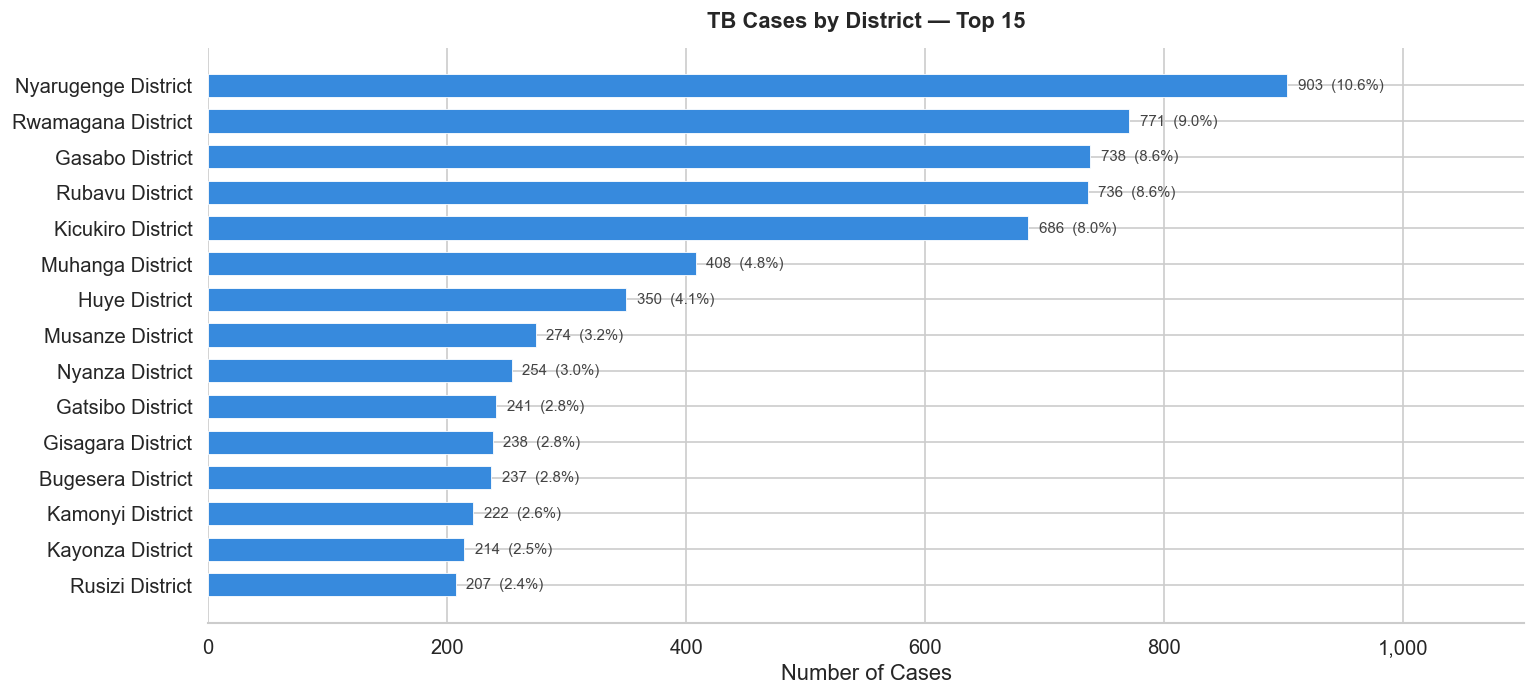


District summary:
  Highest burden : Nyarugenge District  (903 cases, 10.6%)
  Lowest burden  : Nyaruguru District  (71 cases, 0.8%)
  Top 3 districts account for 28.2% of all cases
  Districts contributing 50% of cases: 7


In [26]:

if 'district' in df.columns:
 
    dist = (df['district']
            .value_counts()
            .reset_index()
            .rename(columns={'district': 'District', 'count': 'Cases'}))
    dist['Cases']       = dist['Cases'].astype(int)          # no 423.0 labels
    dist['%']           = (dist['Cases'] / total * 100).round(1)
    dist['Cumulative%'] = dist['%'].cumsum().round(1)
 
    print(f'Cases by District — all {len(dist)} districts:\n')
    display(dist)
 
    # ── Horizontal bar: top 15 
    top15     = dist.head(15).copy()
    x_max     = top15['Cases'].max()
    label_pad = x_max * 0.01
    x_limit   = x_max * 1.22
 
    fig, ax = plt.subplots(figsize=(13, 6))
    bars = ax.barh(
        top15['District'][::-1],
        top15['Cases'][::-1],
        color=BLUE, edgecolor='white', linewidth=0.5, height=0.65
    )
    for bar, pct in zip(bars, top15['%'][::-1]):
        ax.text(
            bar.get_width() + label_pad,
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}  ({pct}%)',
            va='center', ha='left', fontsize=9, color='#444'
        )
    ax.set_xlim(0, x_limit)
    ax.set_title('TB Cases by District — Top 15', fontweight='bold', pad=12)
    ax.set_xlabel('Number of Cases')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.savefig('fig_1_2_district.png', bbox_inches='tight', dpi=150)
    plt.show()
 
    # ── Plotly interactive: all districts 
    fig_px = px.bar(
        dist, x='Cases', y='District', orientation='h',
        text='%', color='Cases', color_continuous_scale='Blues',
        title=f'TB Cases by District — all {len(dist)} districts (2023–2024)',
        template='plotly_white',
        height=max(450, len(dist) * 24)
    )
    fig_px.update_traces(
        texttemplate='%{text}%',
        textposition='outside',
        marker_line_width=0
    )
    fig_px.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        coloraxis_showscale=False,
        xaxis_title='Number of Cases',
        yaxis_title='',
        margin=dict(l=160, r=100, t=60, b=40),
        font=dict(size=12)
    )
    fig_px.write_html('fig_1_2_district_interactive.html')
    fig_px.show()
 
    # ── District summary stats 
    top50_n = int((dist['Cumulative%'] <= 50).sum()) + 1
    print(f'\nDistrict summary:')
    print(f'  Highest burden : {dist.iloc[0]["District"]}  '
          f'({dist.iloc[0]["Cases"]:,} cases, {dist.iloc[0]["%"]}%)')
    print(f'  Lowest burden  : {dist.iloc[-1]["District"]}  '
          f'({dist.iloc[-1]["Cases"]:,} cases, {dist.iloc[-1]["%"]}%)')
    print(f'  Top 3 districts account for {dist.head(3)["%"].sum():.1f}% of all cases')
    print(f'  Districts contributing 50% of cases: {top50_n}')

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.3 — Cases by health facility (top 20)
# ════════════════════════════════════════════════════════════════════════════════

Cases by Health Facility — top 20 of 536:



,Facility,Cases,%
0,Rwamagana Prison,544,6.4
1,Rubavu Prison,386,4.5
2,Rwanda Military Hospital,278,3.3
3,CHK(CHUK) HNR,264,3.1
4,Muhanga Prison,166,1.9
5,Masaka DH,137,1.6
6,Kibagabaga DH,129,1.5
7,Nyarugenge DH,123,1.4
8,Gisenyi DH,120,1.4
9,Remera (Gasabo) CS,110,1.3


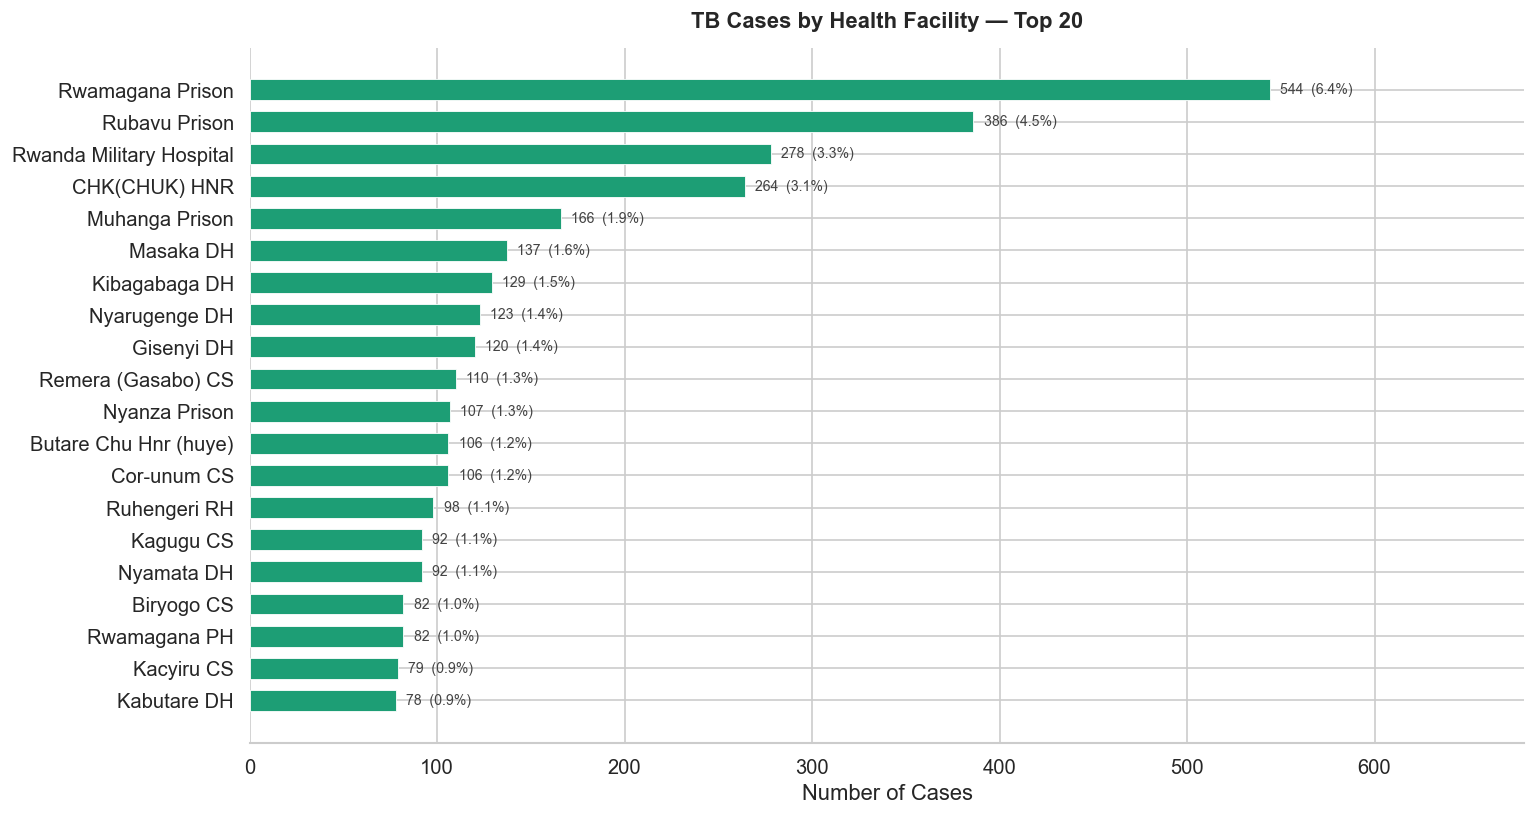

In [27]:

if 'facility' in df.columns:
 
    fac = (df['facility']
           .value_counts()
           .reset_index()
           .rename(columns={'facility': 'Facility', 'count': 'Cases'}))
    fac['Cases'] = fac['Cases'].astype(int)
    fac['%']     = (fac['Cases'] / total * 100).round(1)
 
    print(f'Cases by Health Facility — top 20 of {len(fac)}:\n')
    display(fac.head(20))
 
    top20f    = fac.head(20).copy()
    x_max_f   = top20f['Cases'].max()
    x_limit_f = x_max_f * 1.25
 
    fig, ax = plt.subplots(figsize=(13, 7))
    bars = ax.barh(
        top20f['Facility'][::-1],
        top20f['Cases'][::-1],
        color=TEAL, edgecolor='white', linewidth=0.5, height=0.65
    )
    for bar, pct in zip(bars, top20f['%'][::-1]):
        ax.text(
            bar.get_width() + x_max_f * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}  ({pct}%)',
            va='center', ha='left', fontsize=8.5, color='#444'
        )
    ax.set_xlim(0, x_limit_f)
    ax.set_title('TB Cases by Health Facility — Top 20', fontweight='bold', pad=12)
    ax.set_xlabel('Number of Cases')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(left=True)
    plt.tight_layout()
    plt.savefig('fig_1_3_facility.png', bbox_inches='tight', dpi=150)
    plt.show()

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.4 — Cases by year, month, quarter, fiscal year
# ════════════════════════════════════════════════════════════════════════════════

Cases by Year:


,Year,Cases,%
0,2023,3411,39.9
1,2024,3364,39.4



Cases by Fiscal Year:


,Fiscal Year,Cases
0,2022,7
1,2023,5162
2,2024,1606



Cases by Quarter:


,Quarter,Cases
0,Q1,1765
1,Q2,1603
2,Q3,1781
3,Q4,1626



Cases by Month:


,Month_Name,Cases
0,Jan,596
1,Feb,592
2,Mar,577
3,Apr,648
4,May,523
5,Jun,432
6,Jul,584
7,Aug,656
8,Sep,541
9,Oct,564


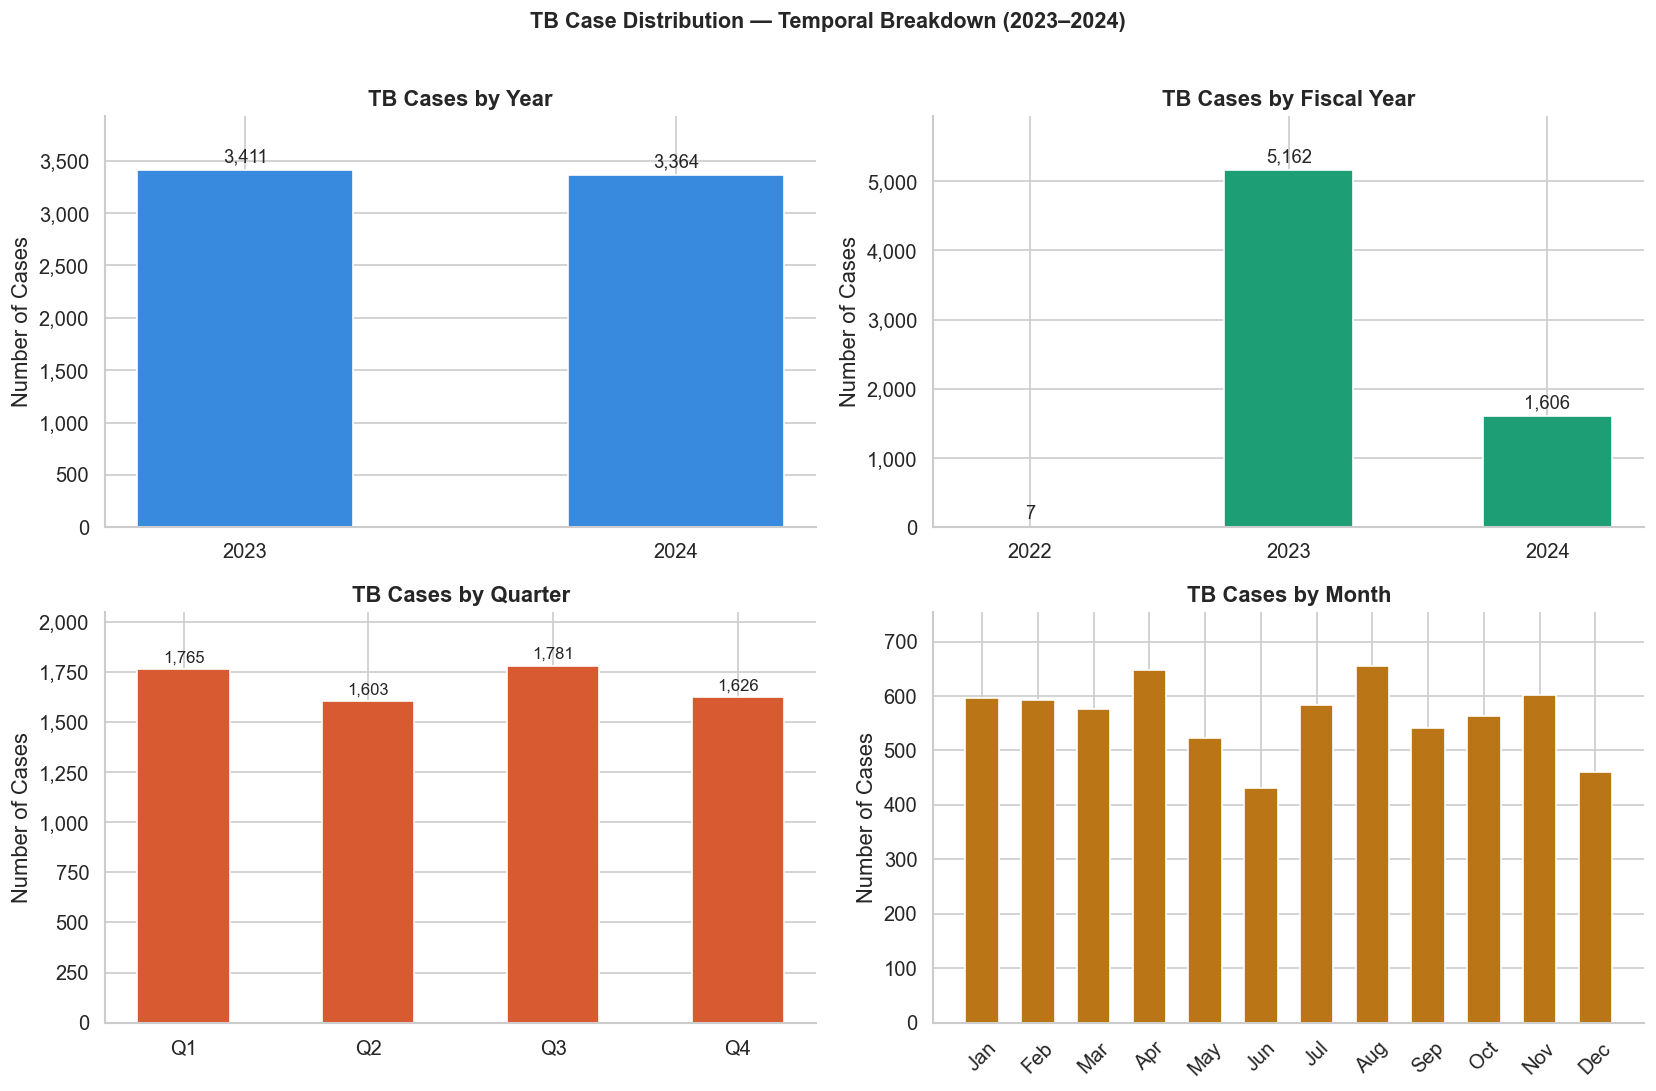

In [28]:
# ── By year ───────────────────────────────────────────────────────────────────
yr = (df['year'].dropna()
      .astype(int)                           # Int64 → int for clean string cast
      .value_counts()
      .sort_index()
      .reset_index()
      .rename(columns={'year': 'Year', 'count': 'Cases'}))
yr['Cases'] = yr['Cases'].astype(int)
yr['Year']  = yr['Year'].astype(str)         # string → discrete axis, no decimals
yr['%']     = (yr['Cases'] / total * 100).round(1)
print('Cases by Year:')
display(yr)
 
# ── By fiscal year ────────────────────────────────────────────────────────────
fy_tbl = (df['fy'].dropna()
          .astype(int)
          .value_counts()
          .sort_index()
          .reset_index()
          .rename(columns={'fy': 'Fiscal Year', 'count': 'Cases'}))
fy_tbl['Cases']       = fy_tbl['Cases'].astype(int)
fy_tbl['Fiscal Year'] = fy_tbl['Fiscal Year'].astype(str)
print('\nCases by Fiscal Year:')
display(fy_tbl)
 
# ── By quarter ────────────────────────────────────────────────────────────────
qtr = (df['quarter'].dropna()
       .astype(int)
       .value_counts()
       .sort_index()
       .reset_index()
       .rename(columns={'quarter': 'Quarter', 'count': 'Cases'}))
qtr['Cases']   = qtr['Cases'].astype(int)
qtr['Quarter'] = qtr['Quarter'].apply(lambda q: f'Q{int(q)}')
print('\nCases by Quarter:')
display(qtr)
 
# ── By month ──────────────────────────────────────────────────────────────────
MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
mon = (df['month'].dropna()
       .astype(int)
       .value_counts()
       .sort_index()
       .reset_index()
       .rename(columns={'month': 'Month', 'count': 'Cases'}))
mon['Cases']      = mon['Cases'].astype(int)
mon['Month_Name'] = mon['Month'].map(MONTH_NAMES)
print('\nCases by Month:')
display(mon[['Month_Name', 'Cases']])
 
# ── 2×2 temporal figure ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax0, ax1, ax2, ax3 = axes.flatten()
 
# Year
bars0 = ax0.bar(yr['Year'], yr['Cases'], color=BLUE, edgecolor='white', width=0.5)
ax0.set_title('TB Cases by Year', fontweight='bold')
ax0.set_ylabel('Number of Cases')
for bar in bars0:
    ax0.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + yr['Cases'].max() * 0.01,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=11)
ax0.set_ylim(0, yr['Cases'].max() * 1.15)
 
# Fiscal year
bars1 = ax1.bar(fy_tbl['Fiscal Year'], fy_tbl['Cases'],
                color=TEAL, edgecolor='white', width=0.5)
ax1.set_title('TB Cases by Fiscal Year', fontweight='bold')
ax1.set_ylabel('Number of Cases')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + fy_tbl['Cases'].max() * 0.01,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=11)
ax1.set_ylim(0, fy_tbl['Cases'].max() * 1.15)
 
# Quarter
bars2 = ax2.bar(qtr['Quarter'], qtr['Cases'], color=CORAL, edgecolor='white', width=0.5)
ax2.set_title('TB Cases by Quarter', fontweight='bold')
ax2.set_ylabel('Number of Cases')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + qtr['Cases'].max() * 0.01,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=10)
ax2.set_ylim(0, qtr['Cases'].max() * 1.15)
 
# Month
bars3 = ax3.bar(mon['Month_Name'], mon['Cases'], color=AMBER, edgecolor='white', width=0.6)
ax3.set_title('TB Cases by Month', fontweight='bold')
ax3.set_ylabel('Number of Cases')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, mon['Cases'].max() * 1.15)
 
for ax in [ax0, ax1, ax2, ax3]:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax)
 
plt.suptitle('TB Case Distribution — Temporal Breakdown (2023–2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_1_4_temporal.png', bbox_inches='tight', dpi=150)
plt.show()
 

## Interpretation — TB Case Distribution Temporal Breakdown (2023–2024)

---

### 1. TB Cases by Year (top left)

| Year | Cases |
|---|---|
| 2023 | 3,411 |
| 2024 | 3,364 |

The annual case load is **remarkably stable** between the two years — a difference of only 47 cases (1.4% decline). This near-equal distribution confirms the dataset represents a **balanced two-year surveillance cohort** rather than a programme that was expanding or contracting. It also suggests TB notification capacity remained consistent across both years, with no major disruptions to health services, case-finding activities, or reporting systems.

---

### 2. TB Cases by Fiscal Year (top right)

| Fiscal Year | Cases |
|---|---|
| FY2022 | 7 |
| FY2023 | 5,162 |
| FY2024 | 1,606 |

This chart is **misleading at first glance** and requires careful interpretation:

- **FY2022 (7 cases)** — these are the 5 records from late 2022 that survived the year cleaning (cases enrolled in January–March 2022 falling into FY2022 which runs April 2022–March 2023 under a typical April-start fiscal year). This is a data artefact, not a true programme figure.
- **FY2023 (5,162 cases)** — this is the dominant fiscal year because it captures April 2023 through March 2024, pulling cases from both calendar years 2023 and 2024.
- **FY2024 (1,606 cases)** — this covers only April 2024 onward, meaning the dataset ends mid-fiscal-year. This is **not** a true annual total and should never be compared directly to FY2023.

**Recommendation:** Add a footnote whenever presenting the fiscal year chart stating that FY2024 is incomplete and represents only the portion of the fiscal year captured in the dataset.

---

### 3. TB Cases by Quarter (bottom left)

| Quarter | Cases |
|---|---|
| Q1 (Jan–Mar) | 1,765 |
| Q2 (Apr–Jun) | 1,603 |
| Q3 (Jul–Sep) | 1,781 |
| Q4 (Oct–Dec) | 1,626 |

Quarterly distribution is **nearly uniform**, ranging from 1,603 to 1,781 — a difference of only 178 cases across quarters. Two observations stand out:

- **Q1 and Q3 are the peak quarters** (1,765 and 1,781 respectively), both corresponding to the start of the dry seasons in Rwanda (January–March and July–September).
- **Q2 and Q4 are the trough quarters** (1,603 and 1,626), coinciding with Rwanda's two rainy seasons (April–June and October–December).

This pattern is **epidemiologically consistent** with TB seasonality literature for sub-Saharan Africa — dry seasons favour airborne transmission due to reduced ventilation (people congregate indoors), lower humidity, and longer survival of *Mycobacterium tuberculosis* in aerosols. The pattern is subtle but present and warrants formal seasonality testing in Section 3.

---

### 4. TB Cases by Month (bottom right)

| Month | Cases | Pattern |
|---|---|---|
| Jan | ~600 | Elevated |
| Feb | ~595 | Elevated |
| Mar | ~580 | Slightly declining |
| Apr | ~650 | **Peak — highest month** |
| May | ~525 | Sharp drop |
| Jun | ~430 | **Trough — lowest month** |
| Jul | ~585 | Recovery |
| Aug | ~655 | **Second peak** |
| Sep | ~545 | Declining |
| Oct | ~555 | Moderate |
| Nov | ~600 | Rising |
| Dec | ~460 | **Second trough** |

Four key observations:

**April is the highest month** (~650 cases). This corresponds to the end of the long dry season (January–March) when transmission has been building for three months and cases are now being diagnosed and registered.

**June is the lowest month** (~430 cases) — a drop of ~220 cases from April. June falls in the middle of Rwanda's long rainy season (March–May). The lag between reduced transmission in rainy season and reduced notifications is approximately 6–8 weeks, consistent with the TB incubation and symptom-onset timeline.

**August is the second peak** (~655 cases), mirroring the April peak but driven by the short dry season (July–August). The short dry season produces a peak almost as large as the long dry season, suggesting Rwanda's TB transmission is highly sensitive to seasonal climate patterns.

**December is the second trough** (~460 cases), again consistent with the short rainy season (October–November) suppressing transmission 6–8 weeks earlier.

---

### Overall Summary for Reporting

> TB case notifications in Rwanda were stable across 2023 and 2024 (3,411 vs 3,364 cases respectively), with no evidence of programme expansion or contraction. A bimodal seasonal pattern was observed, with transmission peaks in April and August coinciding with the end of Rwanda's dry seasons and troughs in June and December coinciding with the rainy seasons. Quarterly analysis confirms Q1 and Q3 as consistently higher-burden periods. These seasonal patterns have direct implications for programme planning — case-finding activities, GeneXpert testing campaigns, and contact tracing should be intensified in January–March and July–August to intercept the transmission wave before it produces the April and August notification peaks.

Cases by Sex:


,Sex,Cases,%
0,Male,6278,73.5
1,Female,2261,26.5
2,Unknown,1,0.0


Male-to-Female ratio: 2.78:1


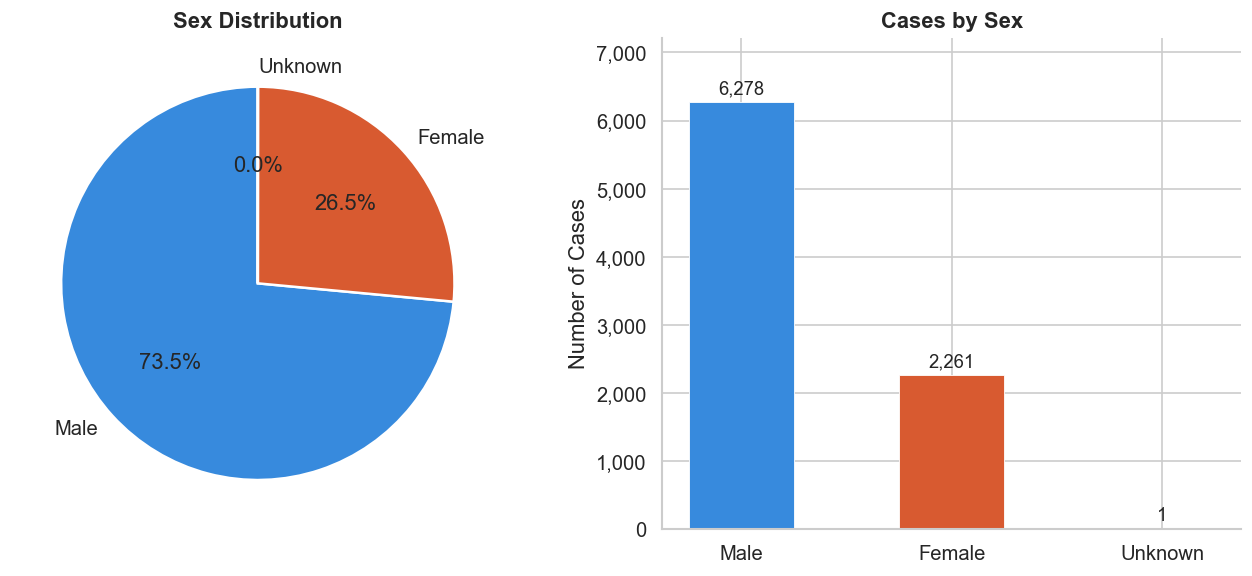

In [29]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.5 — Cases by sex
# ════════════════════════════════════════════════════════════════════════════════
if 'sex' in df.columns:
 
    sex_tbl = (df['sex'].value_counts()
               .reset_index()
               .rename(columns={'sex': 'Sex', 'count': 'Cases'}))
    sex_tbl['Cases'] = sex_tbl['Cases'].astype(int)
    sex_tbl['%']     = (sex_tbl['Cases'] / total * 100).round(1)
    print('Cases by Sex:')
    display(sex_tbl)
 
    # Detect male / female labels
    sex_vals     = df['sex'].dropna().unique().tolist()
    male_label   = next((s for s in sex_vals if str(s).lower() in ['male','m']),   None)
    female_label = next((s for s in sex_vals if str(s).lower() in ['female','f']), None)
    if male_label and female_label:
        m_n = int(df['sex'].eq(male_label).sum())
        f_n = int(df['sex'].eq(female_label).sum())
        print(f'Male-to-Female ratio: {m_n/f_n:.2f}:1')
 
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    colors_sex = [BLUE, CORAL, TEAL, AMBER]
 
    # Pie
    axes[0].pie(sex_tbl['Cases'], labels=sex_tbl['Sex'],
                autopct='%1.1f%%', startangle=90,
                colors=colors_sex[:len(sex_tbl)],
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    axes[0].set_title('Sex Distribution', fontweight='bold')
 
    # Bar
    bars = axes[1].bar(sex_tbl['Sex'], sex_tbl['Cases'],
                       color=colors_sex[:len(sex_tbl)],
                       edgecolor='white', linewidth=0.5, width=0.5)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + sex_tbl['Cases'].max() * 0.01,
                     f'{int(bar.get_height()):,}',
                     ha='center', va='bottom', fontsize=11)
    axes[1].set_ylim(0, sex_tbl['Cases'].max() * 1.15)
    axes[1].set_title('Cases by Sex', fontweight='bold')
    axes[1].set_ylabel('Number of Cases')
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=axes[1])
 
    plt.tight_layout()
    plt.savefig('fig_1_5_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
 

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.6 — Cases by age group
# ════════════════════════════════════════════════════════════════════════════════

Cases by Age Group:


,Age Group,Cases,%
0,0–4,613,7.2
1,5–14,145,1.7
2,15–24,1130,13.2
3,25–34,1992,23.3
4,35–44,1951,22.8
5,45–54,1056,12.4
6,55–64,862,10.1
7,65+,791,9.3


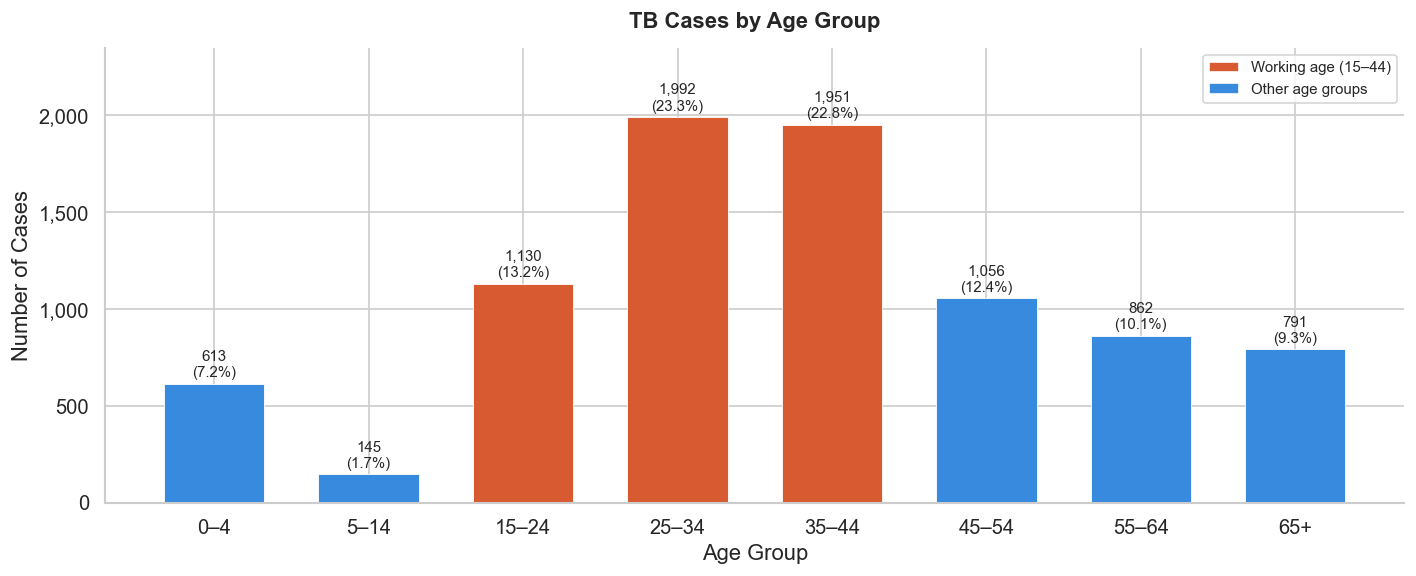

In [30]:

if 'age_group' in df.columns:
 
    age_tbl = (df['age_group'].value_counts()
               .sort_index()
               .reset_index()
               .rename(columns={'age_group': 'Age Group', 'count': 'Cases'}))
    age_tbl['Cases']      = age_tbl['Cases'].astype(int)
    age_tbl['Age Group']  = age_tbl['Age Group'].astype(str)
    age_tbl['%']          = (age_tbl['Cases'] / total * 100).round(1)
    print('Cases by Age Group:')
    display(age_tbl)
 
    # Highlight working-age bars differently
    working_age = ['15–24', '25–34', '35–44']
    bar_colors  = [CORAL if str(ag) in working_age else BLUE
                   for ag in age_tbl['Age Group']]
 
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(age_tbl['Age Group'], age_tbl['Cases'],
                  color=bar_colors, edgecolor='white', linewidth=0.5, width=0.65)
 
    for bar, pct in zip(bars, age_tbl['%']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + age_tbl['Cases'].max() * 0.01,
                f'{int(bar.get_height()):,}\n({pct}%)',
                ha='center', va='bottom', fontsize=9)
 
    ax.set_ylim(0, age_tbl['Cases'].max() * 1.18)
    ax.set_title('TB Cases by Age Group', fontweight='bold', pad=12)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Number of Cases')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
 
    # Legend for colours
    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=CORAL, label='Working age (15–44)'),
                  Patch(facecolor=BLUE,  label='Other age groups')]
    ax.legend(handles=legend_els, frameon=True, fontsize=9)
 
    sns.despine()
    plt.tight_layout()
    plt.savefig('fig_1_6_age_group.png', bbox_inches='tight', dpi=150)
    plt.show()
 

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.7 — Age statistics + histogram + box plot by sex
# ════════════════════════════════════════════════════════════════════════════════

Age Summary Statistics
  Mean   : 37.7 years
  Median : 36.0 years
  SD     : 18.7 years
  IQR    : 26 – 49 years
  Range  : 0 – 104 years
  N      : 8,540


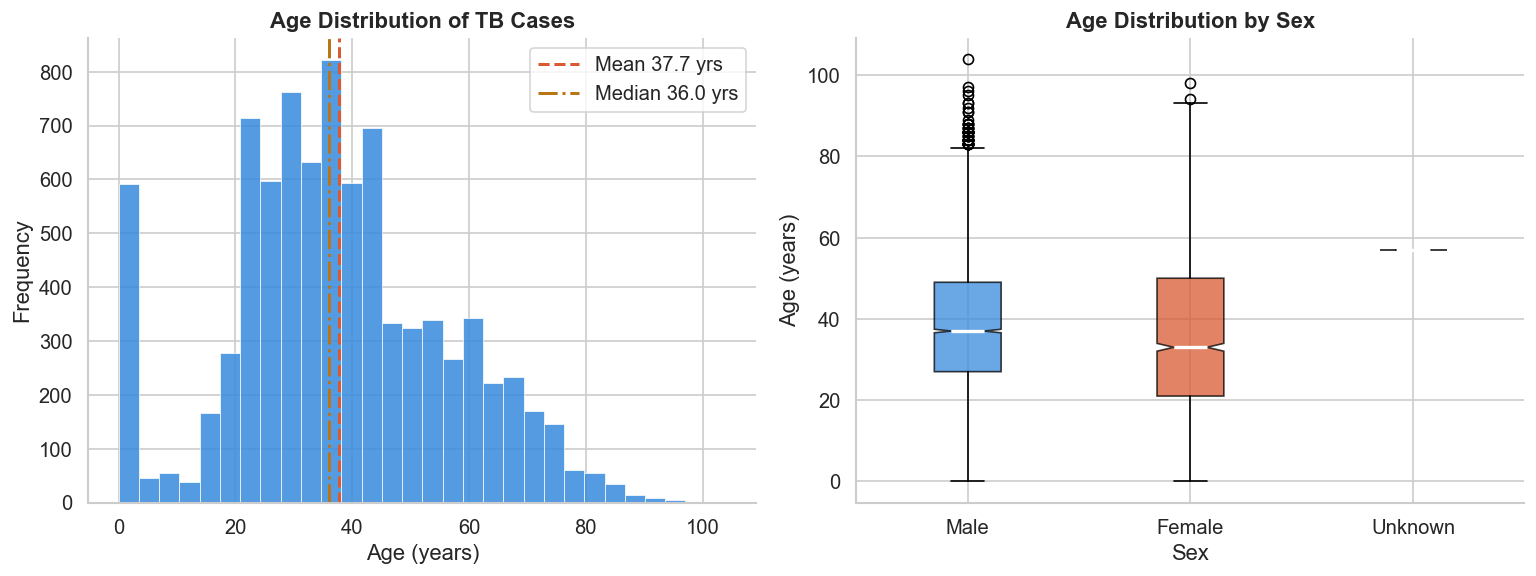

In [31]:

if 'age' in df.columns:
 
    age_clean  = df['age'].dropna()
    mean_age   = age_clean.mean()
    median_age = age_clean.median()
    std_age    = age_clean.std()
    q25, q75   = age_clean.quantile([0.25, 0.75])
 
    print('Age Summary Statistics')
    print(f'  Mean   : {mean_age:.1f} years')
    print(f'  Median : {median_age:.1f} years')
    print(f'  SD     : {std_age:.1f} years')
    print(f'  IQR    : {q25:.0f} – {q75:.0f} years')
    print(f'  Range  : {age_clean.min():.0f} – {age_clean.max():.0f} years')
    print(f'  N      : {len(age_clean):,}')
 
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
    # Histogram
    axes[0].hist(age_clean, bins=30, color=BLUE, edgecolor='white',
                 linewidth=0.5, alpha=0.85)
    axes[0].axvline(mean_age,   color=CORAL, linestyle='--',
                    linewidth=1.8, label=f'Mean {mean_age:.1f} yrs')
    axes[0].axvline(median_age, color=AMBER, linestyle='-.',
                    linewidth=1.8, label=f'Median {median_age:.1f} yrs')
    axes[0].set_title('Age Distribution of TB Cases', fontweight='bold')
    axes[0].set_xlabel('Age (years)')
    axes[0].set_ylabel('Frequency')
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axes[0].legend(frameon=True)
    sns.despine(ax=axes[0])
 
    # Box plot by sex
    if 'sex' in df.columns:
        df_age_sex = df[['age', 'sex']].dropna()
        sex_order  = df_age_sex['sex'].value_counts().index.tolist()
        bp = axes[1].boxplot(
            [df_age_sex[df_age_sex['sex'] == s]['age'].values for s in sex_order],
            labels=sex_order, patch_artist=True, notch=True,
            medianprops={'color': 'white', 'linewidth': 2}
        )
        colors_box = [BLUE, CORAL, TEAL, AMBER]
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        axes[1].set_title('Age Distribution by Sex', fontweight='bold')
        axes[1].set_xlabel('Sex')
        axes[1].set_ylabel('Age (years)')
        sns.despine(ax=axes[1])
 
    plt.tight_layout()
    plt.savefig('fig_1_7_age_dist.png', bbox_inches='tight', dpi=150)
    plt.show()
 

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.8 — Age-Sex Pyramid
# ════════════════════════════════════════════════════════════════════════════════

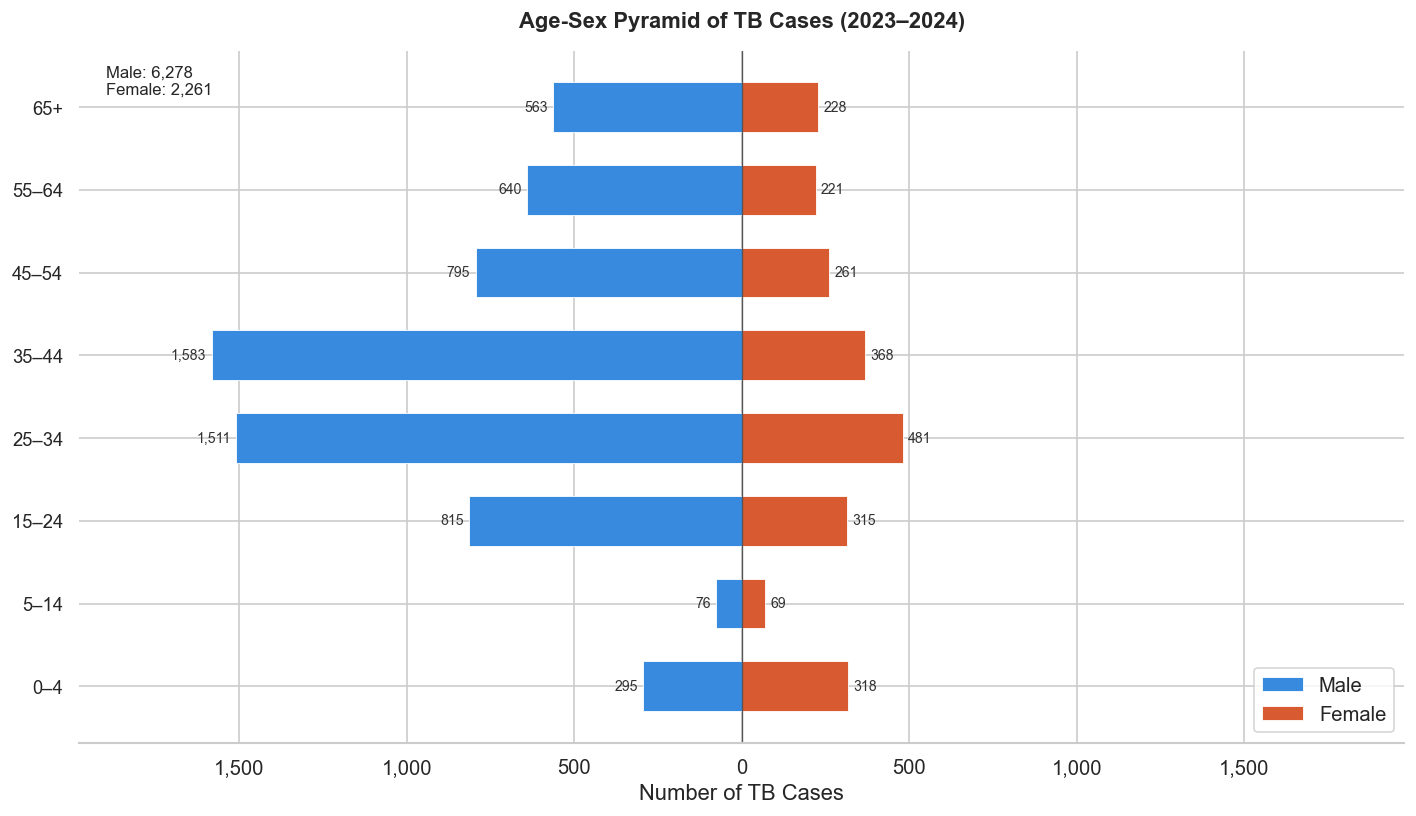

Age-Sex Pyramid — Detailed Table:


,Female,Male,Unknown,Total,% of all,M:F ratio
0–4,318,295,0,613,7.2,0.93
5–14,69,76,0,145,1.7,1.10
15–24,315,815,0,1130,13.2,2.59
25–34,481,1511,0,1992,23.3,3.14
35–44,368,1583,0,1951,22.8,4.30
45–54,261,795,0,1056,12.4,3.05
55–64,221,640,1,862,10.1,2.90
65+,228,563,0,791,9.3,2.47


In [32]:

if 'age_group' in df.columns and 'sex' in df.columns:
 
    sex_vals     = df['sex'].dropna().unique().tolist()
    male_label   = next((s for s in sex_vals if str(s).lower() in ['male','m']),   sex_vals[0])
    female_label = next((s for s in sex_vals if str(s).lower() in ['female','f']),
                        [s for s in sex_vals if s != male_label][0])
 
    pyramid = (df.groupby(['age_group', 'sex'], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(index=df['age_group'].cat.categories))
 
    males      = pyramid.get(male_label,   pd.Series(0, index=pyramid.index)).values.astype(int)
    females    = pyramid.get(female_label, pd.Series(0, index=pyramid.index)).values.astype(int)
    age_labels = pyramid.index.astype(str).tolist()
 
    x_max_pyr = max(males.max(), females.max())
    x_limit_pyr = x_max_pyr * 1.25
 
    fig, ax = plt.subplots(figsize=(12, 7))
    y = np.arange(len(age_labels))
 
    ax.barh(y, -males,  color=BLUE,  edgecolor='white', linewidth=0.5,
            label=male_label,   height=0.6)
    ax.barh(y,  females, color=CORAL, edgecolor='white', linewidth=0.5,
            label=female_label, height=0.6)
 
    ax.set_yticks(y)
    ax.set_yticklabels(age_labels, fontsize=11)
    ax.axvline(0, color='#555', linewidth=0.8)
 
    # Value labels — integers, no floats
    label_pad_pyr = x_max_pyr * 0.01
    for i, (m, f) in enumerate(zip(males, females)):
        if m > 0:
            ax.text(-m - label_pad_pyr, i, f'{m:,}',
                    va='center', ha='right', fontsize=8.5, color='#333')
        if f > 0:
            ax.text(f + label_pad_pyr, i, f'{f:,}',
                    va='center', ha='left',  fontsize=8.5, color='#333')
 
    ax.set_xlim(-x_limit_pyr, x_limit_pyr)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{abs(int(x)):,}'))
    ax.set_xlabel('Number of TB Cases')
    ax.set_title('Age-Sex Pyramid of TB Cases (2023–2024)',
                 fontweight='bold', pad=14)
    ax.legend(loc='lower right', frameon=True)
    ax.text(0.02, 0.98,
            f'{male_label}: {int(males.sum()):,}\n{female_label}: {int(females.sum()):,}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
    sns.despine(left=True)
    plt.tight_layout()
    plt.savefig('fig_1_8_age_sex_pyramid.png', bbox_inches='tight', dpi=150)
    plt.show()
 
    # Detailed pyramid table
    pyramid_tbl = pyramid.copy()
    pyramid_tbl.columns.name = None
    pyramid_tbl = pyramid_tbl.astype(int)
    pyramid_tbl['Total']     = pyramid_tbl.sum(axis=1)
    pyramid_tbl['% of all']  = (pyramid_tbl['Total'] / total * 100).round(1)
    if male_label in pyramid_tbl.columns and female_label in pyramid_tbl.columns:
        pyramid_tbl['M:F ratio'] = (
            pyramid_tbl[male_label] /
            pyramid_tbl[female_label].replace(0, np.nan)
        ).round(2)
    print('Age-Sex Pyramid — Detailed Table:')
    display(pyramid_tbl)

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.9 — Age group × district heatmap (top 10 districts)
# ════════════════════════════════════════════════════════════════════════════════

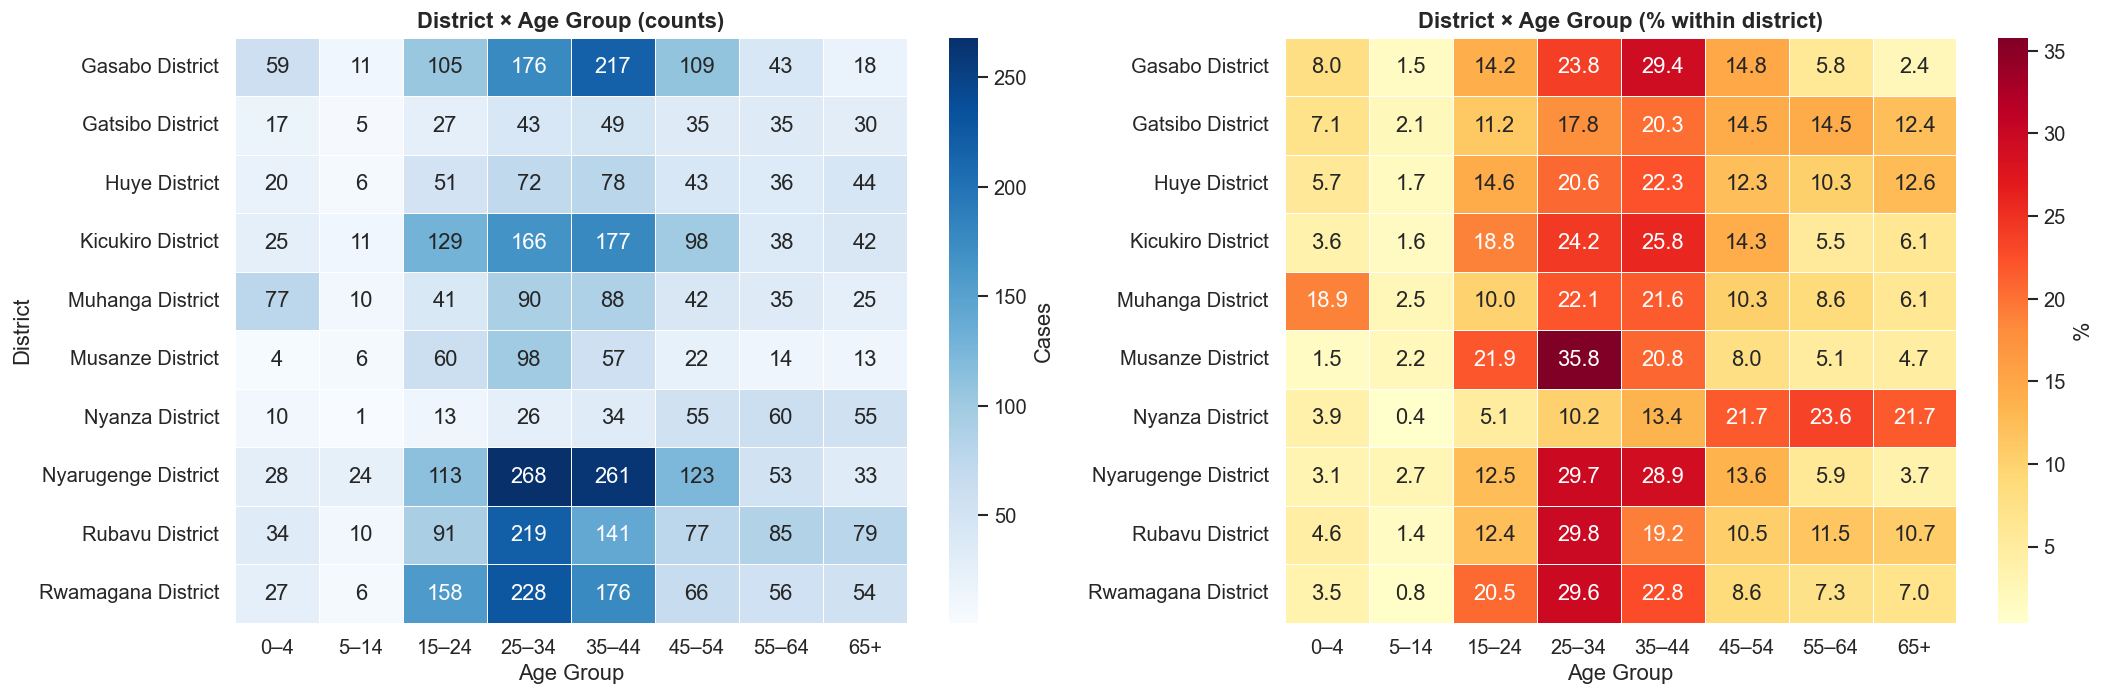

In [33]:

if 'age_group' in df.columns and 'district' in df.columns:
 
    top10_dist = df['district'].value_counts().head(10).index
    df_sub     = df[df['district'].isin(top10_dist)]
 
    ct = (pd.crosstab(df_sub['district'], df_sub['age_group'])
          .reindex(columns=df['age_group'].cat.categories, fill_value=0))
    ct = ct.astype(int)
 
    # Row-normalise to % within each district
    ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
 
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
 
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes[0],
                cbar_kws={'label': 'Cases'})
    axes[0].set_title('District × Age Group (counts)', fontweight='bold')
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel('District')
 
    sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=axes[1],
                cbar_kws={'label': '%'})
    axes[1].set_title('District × Age Group (% within district)', fontweight='bold')
    axes[1].set_xlabel('Age Group')
    axes[1].set_ylabel('')
 
    plt.tight_layout()
    plt.savefig('fig_1_9_district_age_heatmap.png', bbox_inches='tight', dpi=150)
    plt.show()
 

The two heatmaps provide complementary insights: the left panel displays raw case counts per age group for the ten districts with the highest total cases, revealing which districts carry the greatest absolute burden and which age groups contribute most to those totals. The right panel normalizes these counts row‑wise, showing the percentage distribution of cases within each district; this removes the influence of district size and highlights the relative age composition of cases. Together, they allow identification of both high‑burden districts (e.g., darker cells in the counts heatmap) and distinct age‑profile patterns—such as a district where young children or older adults dominate its caseload—that may reflect differences in transmission dynamics, demographic structure, or outbreak control measures.



# ════════════════════════════════════════════════════════════════════════════════
# CELL 1.10 — Export all Section 1 tables to Excel
# ════════════════════════════════════════════════════════════════════════════════

In [35]:

with pd.ExcelWriter('Section1_Descriptive_Summary.xlsx', engine='openpyxl') as writer:
 
    if 'district' in df.columns:
        dist.to_excel(writer, sheet_name='Cases by District', index=False)
 
    if 'facility' in df.columns:
        fac.head(30).to_excel(writer, sheet_name='Cases by Facility', index=False)
 
    yr.to_excel(writer,  sheet_name='Cases by Year',    index=False)
    fy_tbl.to_excel(writer, sheet_name='Cases by FY',   index=False)
    qtr.to_excel(writer, sheet_name='Cases by Quarter', index=False)
    mon[['Month_Name','Cases']].to_excel(
        writer, sheet_name='Cases by Month', index=False)
 
    if 'sex' in df.columns:
        sex_tbl.to_excel(writer, sheet_name='Cases by Sex', index=False)
 
    if 'age_group' in df.columns:
        age_tbl.to_excel(writer, sheet_name='Cases by Age Group', index=False)
        pyramid_tbl.to_excel(writer, sheet_name='Age-Sex Pyramid')
 
    # Key indicators summary sheet
    indicators = {
        'Total cases (2023–2024)': f'{total:,}',
        'Cases in 2023':           f'{yr[yr["Year"]=="2023"]["Cases"].sum():,}'
                                    if "2023" in yr["Year"].values else "N/A",
        'Cases in 2024':           f'{yr[yr["Year"]=="2024"]["Cases"].sum():,}'
                                    if "2024" in yr["Year"].values else "N/A",
        'Mean age (years)':        f'{mean_age:.1f}'   if 'age' in df.columns else 'N/A',
        'Median age (years)':      f'{median_age:.1f}' if 'age' in df.columns else 'N/A',
        'Male:Female ratio':       f'{m_n/f_n:.2f}:1'  if 'sex' in df.columns
                                    and male_label and female_label else 'N/A',
        'Peak age group':          str(age_tbl.loc[age_tbl["Cases"].idxmax(), "Age Group"])
                                    if 'age_group' in df.columns else 'N/A',
        'Number of districts':     str(df['district'].nunique())
                                    if 'district' in df.columns else 'N/A',
        'Number of facilities':    str(df['facility'].nunique())
                                    if 'facility' in df.columns else 'N/A',
        'Top district':            str(dist.iloc[0]['District'])
                                    if 'district' in df.columns else 'N/A',
        'Top district share (%)':  str(dist.iloc[0]['%'])
                                    if 'district' in df.columns else 'N/A',
    }
    pd.DataFrame(list(indicators.items()),
                 columns=['Indicator', 'Value']
                 ).to_excel(writer, sheet_name='Key Indicators', index=False)
 
print('Section 1 complete.')
print('    Excel  : Section1_Descriptive_Summary.xlsx')
print('    Figures: fig_1_2 → fig_1_9  (.png)')
print('    HTML   : fig_1_2_district_interactive.html')

Section 1 complete.
    Excel  : Section1_Descriptive_Summary.xlsx
    Figures: fig_1_2 → fig_1_9  (.png)
    HTML   : fig_1_2_district_interactive.html
